In [134]:
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install tensorflow
%pip install statsmodels
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


...


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [135]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, Input, Model 
from tensorflow.keras.layers import LSTM, Dense, Concatenate, TimeDistributed


Import raw files, drop metadata and convert index to datetime 

In [136]:
# Load datasets
fred_md = pd.read_csv("FRED_MD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")
fred_qd = pd.read_csv("FRED_QD.csv", index_col=0, parse_dates=True, date_format="%m/%d/%Y")

# Drop metadata rows (first row for MD, first two for QD)
fred_md = fred_md.iloc[1:].apply(pd.to_numeric, errors='coerce')
fred_qd = fred_qd.iloc[2:].apply(pd.to_numeric, errors='coerce')

# Convert index to datetime (if not already)
fred_md.index = pd.to_datetime(fred_md.index)
fred_qd.index = pd.to_datetime(fred_qd.index)

Exploratory data analysis 

In [137]:
# 1. Dataset info
print("FRED-MD shape:", fred_md.shape)
print("FRED-QD shape:", fred_qd.shape)

# Monthly features (high-frequency)
monthly_features = [
    "UMCSENTx", "VIXCLSx", "GS10", "TB3MS", "CPIAUCSL", "INDPRO", "M2SL",
    "UNRATE", "PAYEMS", "HOUST", "RETAILx", "BUSINVx", "FEDFUNDS", "M1SL", "PERMIT"
]

# Quarterly features (low-frequency, excluding those duplicated in monthly data)
quarterly_features = [
    "GDPC1",  # Real GDP (target)
    "TCU"     # Capacity Utilization (quarterly only)
]

# --- STEP 5: Select cleaned and aligned dataframes ---
monthly_selected = fred_md[monthly_features]
quarterly_selected = fred_qd[quarterly_features]

# --- STEP 6: Missingness ---
print("Monthly dataset shape:", monthly_selected.shape)
print("Quarterly dataset shape:", quarterly_selected.shape)

print("\nMissing values in monthly data:")
print(monthly_selected.isna().sum().sort_values(ascending=False))

print("\nMissing values in quarterly data:")
print(quarterly_selected.isna().sum().sort_values(ascending=False))

# Calculate percentage of missing values for each feature in the final datasets
monthly_missing_pct = monthly_selected.isna().mean().sort_values(ascending=False) * 100
quarterly_missing_pct = quarterly_selected.isna().mean().sort_values(ascending=False) * 100

monthly_missing_pct, quarterly_missing_pct

FRED-MD shape: (793, 126)
FRED-QD shape: (264, 245)
Monthly dataset shape: (793, 15)
Quarterly dataset shape: (264, 2)

Missing values in monthly data:
UMCSENTx    154
VIXCLSx      42
PERMIT       12
BUSINVx       1
CPIAUCSL      0
TB3MS         0
GS10          0
M2SL          0
INDPRO        0
UNRATE        0
PAYEMS        0
RETAILx       0
HOUST         0
FEDFUNDS      0
M1SL          0
dtype: int64

Missing values in quarterly data:
TCU      32
GDPC1     0
dtype: int64


(UMCSENTx    19.419924
 VIXCLSx      5.296343
 PERMIT       1.513241
 BUSINVx      0.126103
 CPIAUCSL     0.000000
 TB3MS        0.000000
 GS10         0.000000
 M2SL         0.000000
 INDPRO       0.000000
 UNRATE       0.000000
 PAYEMS       0.000000
 RETAILx      0.000000
 HOUST        0.000000
 FEDFUNDS     0.000000
 M1SL         0.000000
 dtype: float64,
 TCU      12.121212
 GDPC1     0.000000
 dtype: float64)

Missing data for UMSCENT and TCU is quite high, so they will be removed. Considering the like VIXCLS only has missing values at the first few years of the dataset (up until july 1962), The first few rows of the montly and quarterly datasets up untill this date will be removed

In [ ]:
# --- STEP 1: Load FRED datasets ---
monthly_df = pd.read_csv("FRED_MD.csv", index_col=0)
quarterly_df = pd.read_csv("FRED_QD.csv", index_col=0)

# --- STEP 2: Parse index with correct format ---
monthly_df.index = pd.to_datetime(monthly_df.index, format="%m/%d/%Y", errors="coerce")
quarterly_df.index = pd.to_datetime(quarterly_df.index, format="%m/%d/%Y", errors="coerce")

# --- STEP 3: Clean metadata rows and convert to numeric ---
monthly_data = monthly_df.iloc[1:].apply(pd.to_numeric, errors='coerce')
quarterly_data = quarterly_df.iloc[2:].apply(pd.to_numeric, errors='coerce')

# --- STEP 5: Define selected features ---
monthly_features = [
    "VIXCLSx", "GS10", "TB3MS", "CPIAUCSL", "INDPRO", "M2SL",
    "UNRATE", "PAYEMS", "HOUST", "RETAILx", "BUSINVx", "FEDFUNDS", "M1SL", "PERMIT"
]
quarterly_features = ["GDPC1"]

# --- STEP 6: Subset features ---
monthly_selected = monthly_data[monthly_features]
quarterly_selected = quarterly_data[quarterly_features]

# --- STEP 7: Trim between 1962-07-01 and 2024-12-31 ---
start_date = pd.Timestamp("1962-07-01")
end_date = pd.Timestamp("2024-12-31")

monthly_trimmed = monthly_selected.loc[(monthly_selected.index >= start_date) & (monthly_selected.index <= end_date)]
quarterly_trimmed = quarterly_selected.loc[(quarterly_selected.index >= start_date) & (quarterly_selected.index <= end_date)]

# --- Final check ---
print("Date Range:", start_date.date(), "to", end_date.date())
print("Monthly shape:", monthly_trimmed.shape)
print("Quarterly shape:", quarterly_trimmed.shape)


Date Range: 1962-07-01 to 2024-12-31
Monthly shape: (750, 14)
Quarterly shape: (250, 1)


Check if the data doesnt contain any missing values anymore: Yes!

In [139]:
monthly_missing_trimmed = monthly_trimmed.isna().sum().sort_values(ascending=False)
quarterly_missing_trimmed = quarterly_trimmed.isna().sum().sort_values(ascending=False)

# Filter to only show features with any missing values
monthly_missing_trimmed = monthly_missing_trimmed[monthly_missing_trimmed > 0]
quarterly_missing_trimmed = quarterly_missing_trimmed[quarterly_missing_trimmed > 0]

monthly_missing_trimmed, quarterly_missing_trimmed


(Series([], dtype: int64), Series([], dtype: int64))

Plotting monthly and quarterly features 

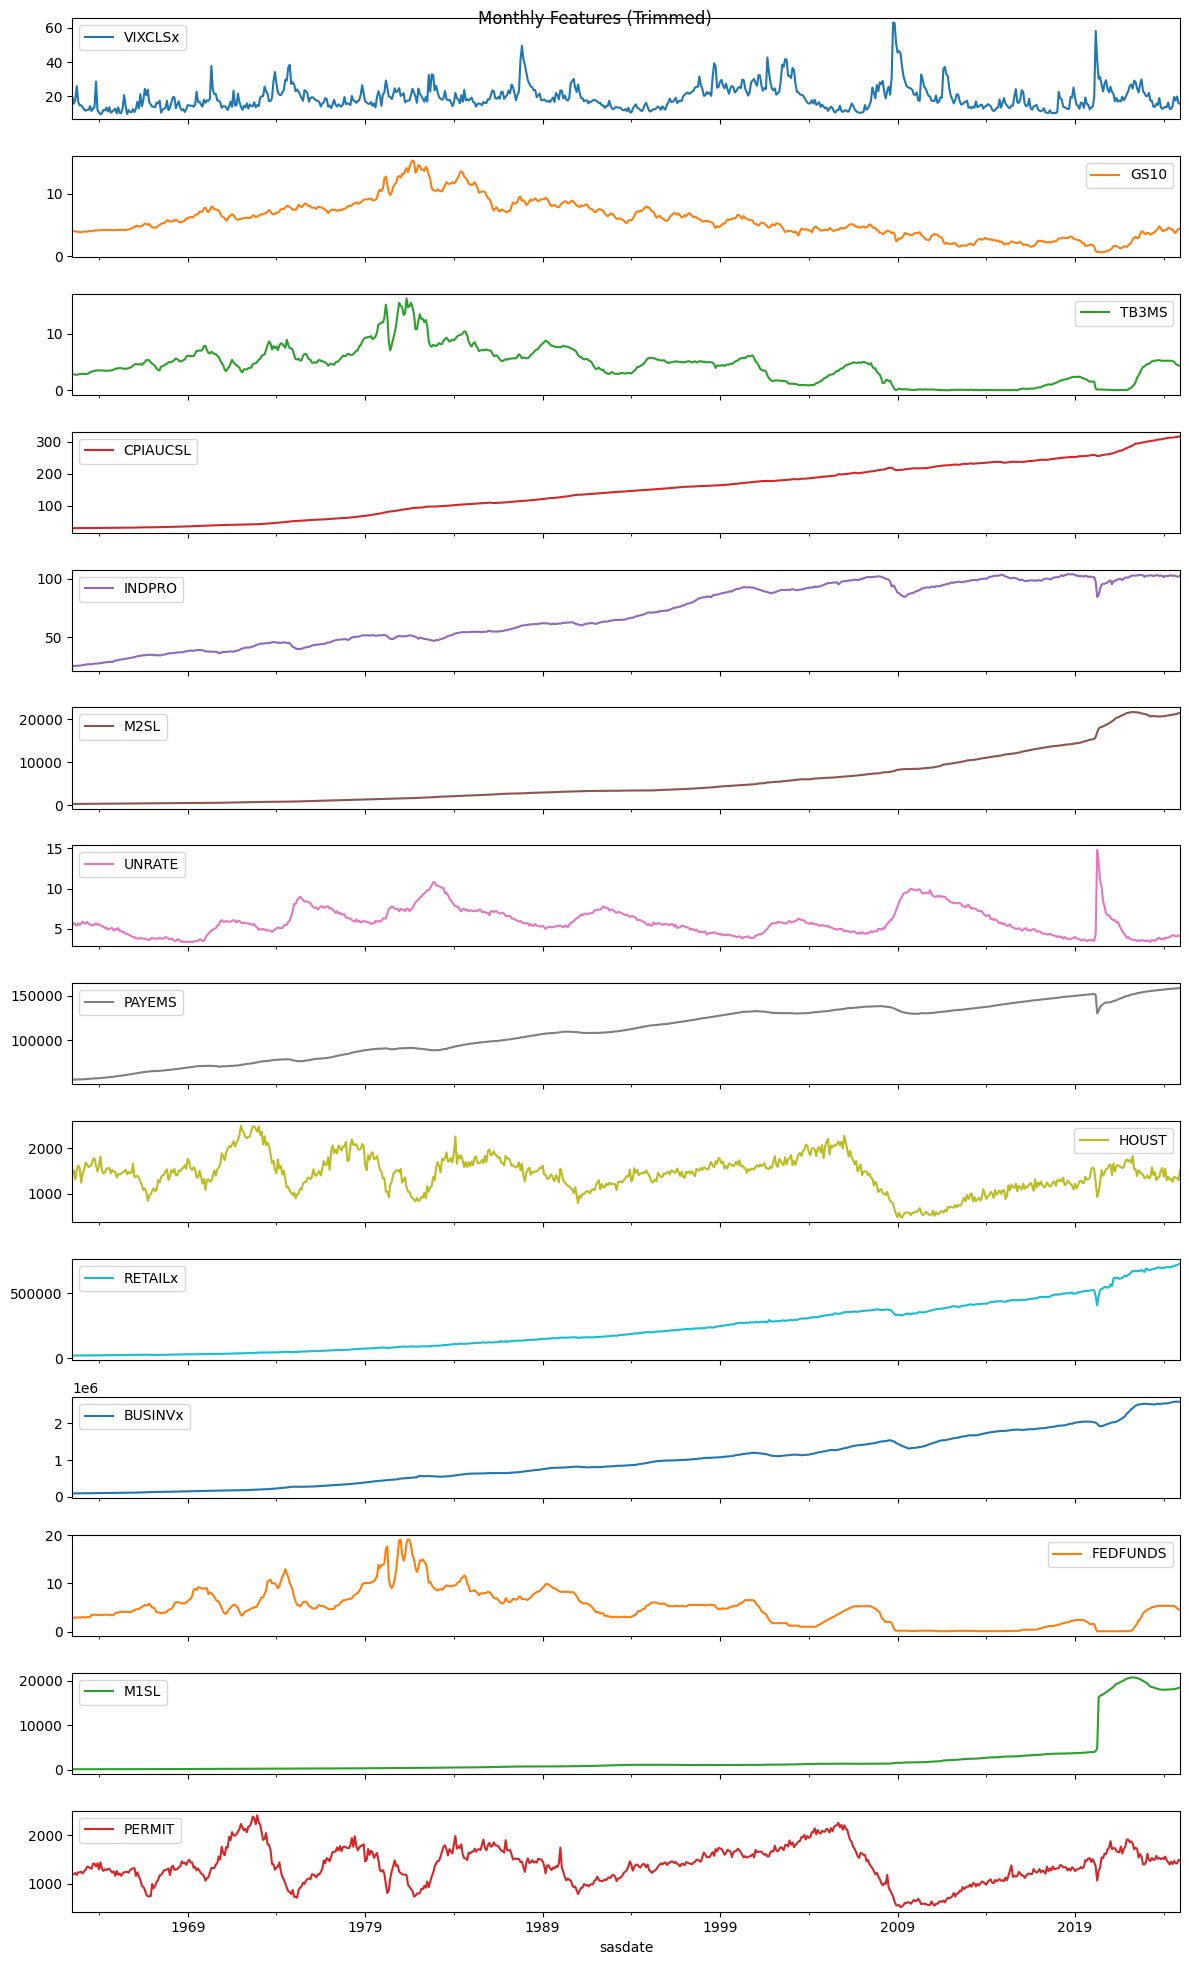

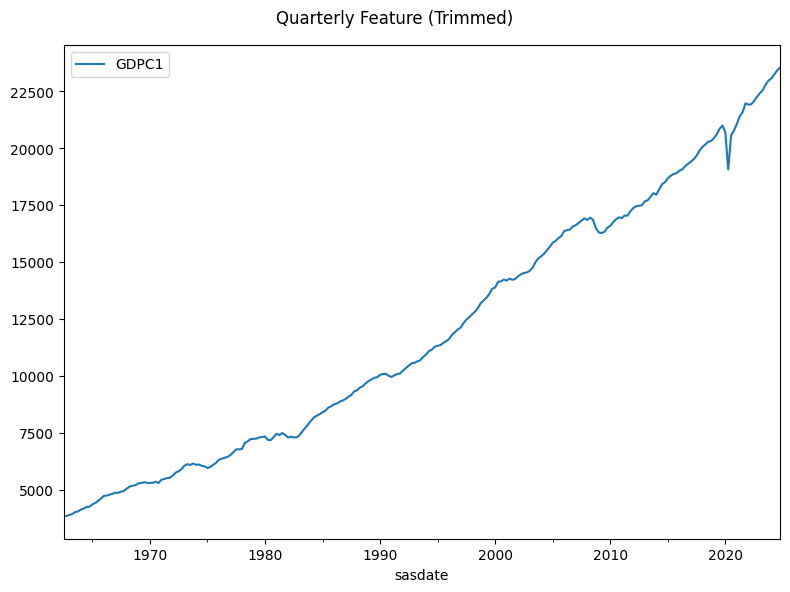

In [140]:
# --- Plot each feature in the monthly dataset ---
monthly_trimmed.plot(subplots=True, figsize=(12, 20), title="Monthly Features (Trimmed)")
plt.tight_layout()
plt.show()

# --- Plot each feature in the quarterly dataset ---
quarterly_trimmed.plot(subplots=True, figsize=(8, 6), title="Quarterly Feature (Trimmed)")
plt.tight_layout()
plt.show()

Table of correlations between downsampled monthly features and GDP 

You can test each series using a unit root test, like the ADF (Augmented Dickey-Fuller) test:

If p-value > 0.05 → non-stationary (you should transform)

If p-value ≤ 0.05 → stationary (you can leave as-is)

In [141]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(df):
    results = {}
    for col in df.columns:
        series = df[col].dropna()
        adf_result = adfuller(series)
        results[col] = {
            "ADF Statistic": adf_result[0],
            "p-value": adf_result[1],
            "Stationary": adf_result[1] <= 0.05
        }
    return pd.DataFrame(results).T.sort_values("p-value")

stationarity_report_monthly = check_stationarity(monthly_trimmed)
stationarity_report_quarterly = check_stationarity(quarterly_trimmed)
display(stationarity_report_monthly)
display(stationarity_report_quarterly)


,ADF Statistic,p-value,Stationary
VIXCLSx,-5.690442,0.000001,True
PERMIT,-4.044219,0.001196,True
HOUST,-3.891991,0.002095,True
UNRATE,-3.273462,0.016107,True
FEDFUNDS,-2.845179,0.052104,False
TB3MS,-2.245794,0.190047,False
GS10,-1.454811,0.555736,False
INDPRO,-1.182908,0.680905,False
PAYEMS,-0.855674,0.802219,False
M1SL,0.805265,0.991721,False


,ADF Statistic,p-value,Stationary
GDPC1,2.502077,0.999051,False


In [ ]:
# Apply differencing to non-stationary monthly features
non_stationary_monthly = stationarity_report_monthly[stationarity_report_monthly["Stationary"] == False].index.tolist()
monthly_stationary = monthly_trimmed.copy()
monthly_stationary[non_stationary_monthly] = monthly_stationary[non_stationary_monthly].diff()
monthly_stationary = monthly_stationary.dropna()

# Apply differencing to non-stationary quarterly features
non_stationary_quarterly = stationarity_report_quarterly[stationarity_report_quarterly["Stationary"] == False].index.tolist()
quarterly_stationary = quarterly_trimmed.copy()
quarterly_stationary[non_stationary_quarterly] = quarterly_stationary[non_stationary_quarterly].diff()
quarterly_stationary = quarterly_stationary.dropna()

# --- Step 3: Re-check stationarity ---
stationarity_monthly_after = check_stationarity(monthly_stationary)
stationarity_quarterly_after = check_stationarity(quarterly_stationary)

# Display resultsprint
print("✅ Monthly Stationarity After Transformation")
display(stationarity_monthly_after)

print("\n✅ Quarterly Stationarity After Transformation")
display(stationarity_quarterly_after)

✅ Monthly Stationarity After Transformation


,ADF Statistic,p-value,Stationary
PAYEMS,-21.648049,0.0,True
M1SL,-25.14935,0.0,True
GS10,-7.273412,0.0,True
INDPRO,-7.233722,0.0,True
BUSINVx,-6.826855,0.0,True
TB3MS,-6.185071,0.0,True
VIXCLSx,-5.690442,0.000001,True
FEDFUNDS,-5.561232,0.000002,True
RETAILx,-4.342826,0.000374,True
M2SL,-4.324481,0.000403,True



✅ Quarterly Stationarity After Transformation


,ADF Statistic,p-value,Stationary
GDPC1,-17.900518,0.0,True


Add transformed values to the 

In [143]:
# Step 1: Get list of stationary features (those that were not differenced)
stationary_monthly_cols = stationarity_report_monthly[stationarity_report_monthly["Stationary"] == True].index.tolist()
stationary_quarterly_cols = stationarity_report_quarterly[stationarity_report_quarterly["Stationary"] == True].index.tolist()

# Step 2: Create the final monthly dataset
# - Use differenced versions for non-stationary columns
# - Use original trimmed values for stationary columns
final_monthly_stationary = pd.concat([
    monthly_stationary[non_stationary_monthly],  # differenced
    monthly_trimmed[stationary_monthly_cols].loc[monthly_stationary.index]  # original
], axis=1).sort_index(axis=1)

# Step 3: Final quarterly dataset with only GDPC1 (already differenced if needed)
final_quarterly_stationary = quarterly_stationary[["GDPC1"]]

# Output dataset shapes and preview
final_monthly_shape = final_monthly_stationary.shape
final_quarterly_shape = final_quarterly_stationary.shape
final_monthly_stationary.head(), final_quarterly_stationary.head(), final_monthly_shape, final_quarterly_shape


(              BUSINVx  CPIAUCSL  FEDFUNDS  GS10  HOUST  INDPRO  M1SL  M2SL  \
 sasdate                                                                      
 1962-07-01        NaN       NaN       NaN   NaN   1450     NaN   NaN   NaN   
 1962-08-01  467.60372      0.06      0.22 -0.03   1517  0.0269   0.1   2.0   
 1962-09-01  701.40558      0.14     -0.03  0.00   1324  0.1613  -0.3   2.1   
 1962-10-01  506.57070     -0.04      0.00 -0.05   1533  0.0269   0.4   2.3   
 1962-11-01   38.96698      0.00      0.04 -0.01   1622  0.1075   0.6   2.6   
 
             PAYEMS  PERMIT    RETAILx  TB3MS  UNRATE  VIXCLSx  
 sasdate                                                        
 1962-07-01     NaN  1189.0        NaN    NaN     5.4  19.5715  
 1962-08-01    92.0  1200.0  126.52929  -0.10     5.7  15.7942  
 1962-09-01   140.0  1223.0   61.19039  -0.04     5.6  18.3148  
 1962-10-01    63.0  1181.0  322.54596  -0.04     5.4  25.9671  
 1962-11-01    15.0  1236.0  108.89816   0.09     5.7  

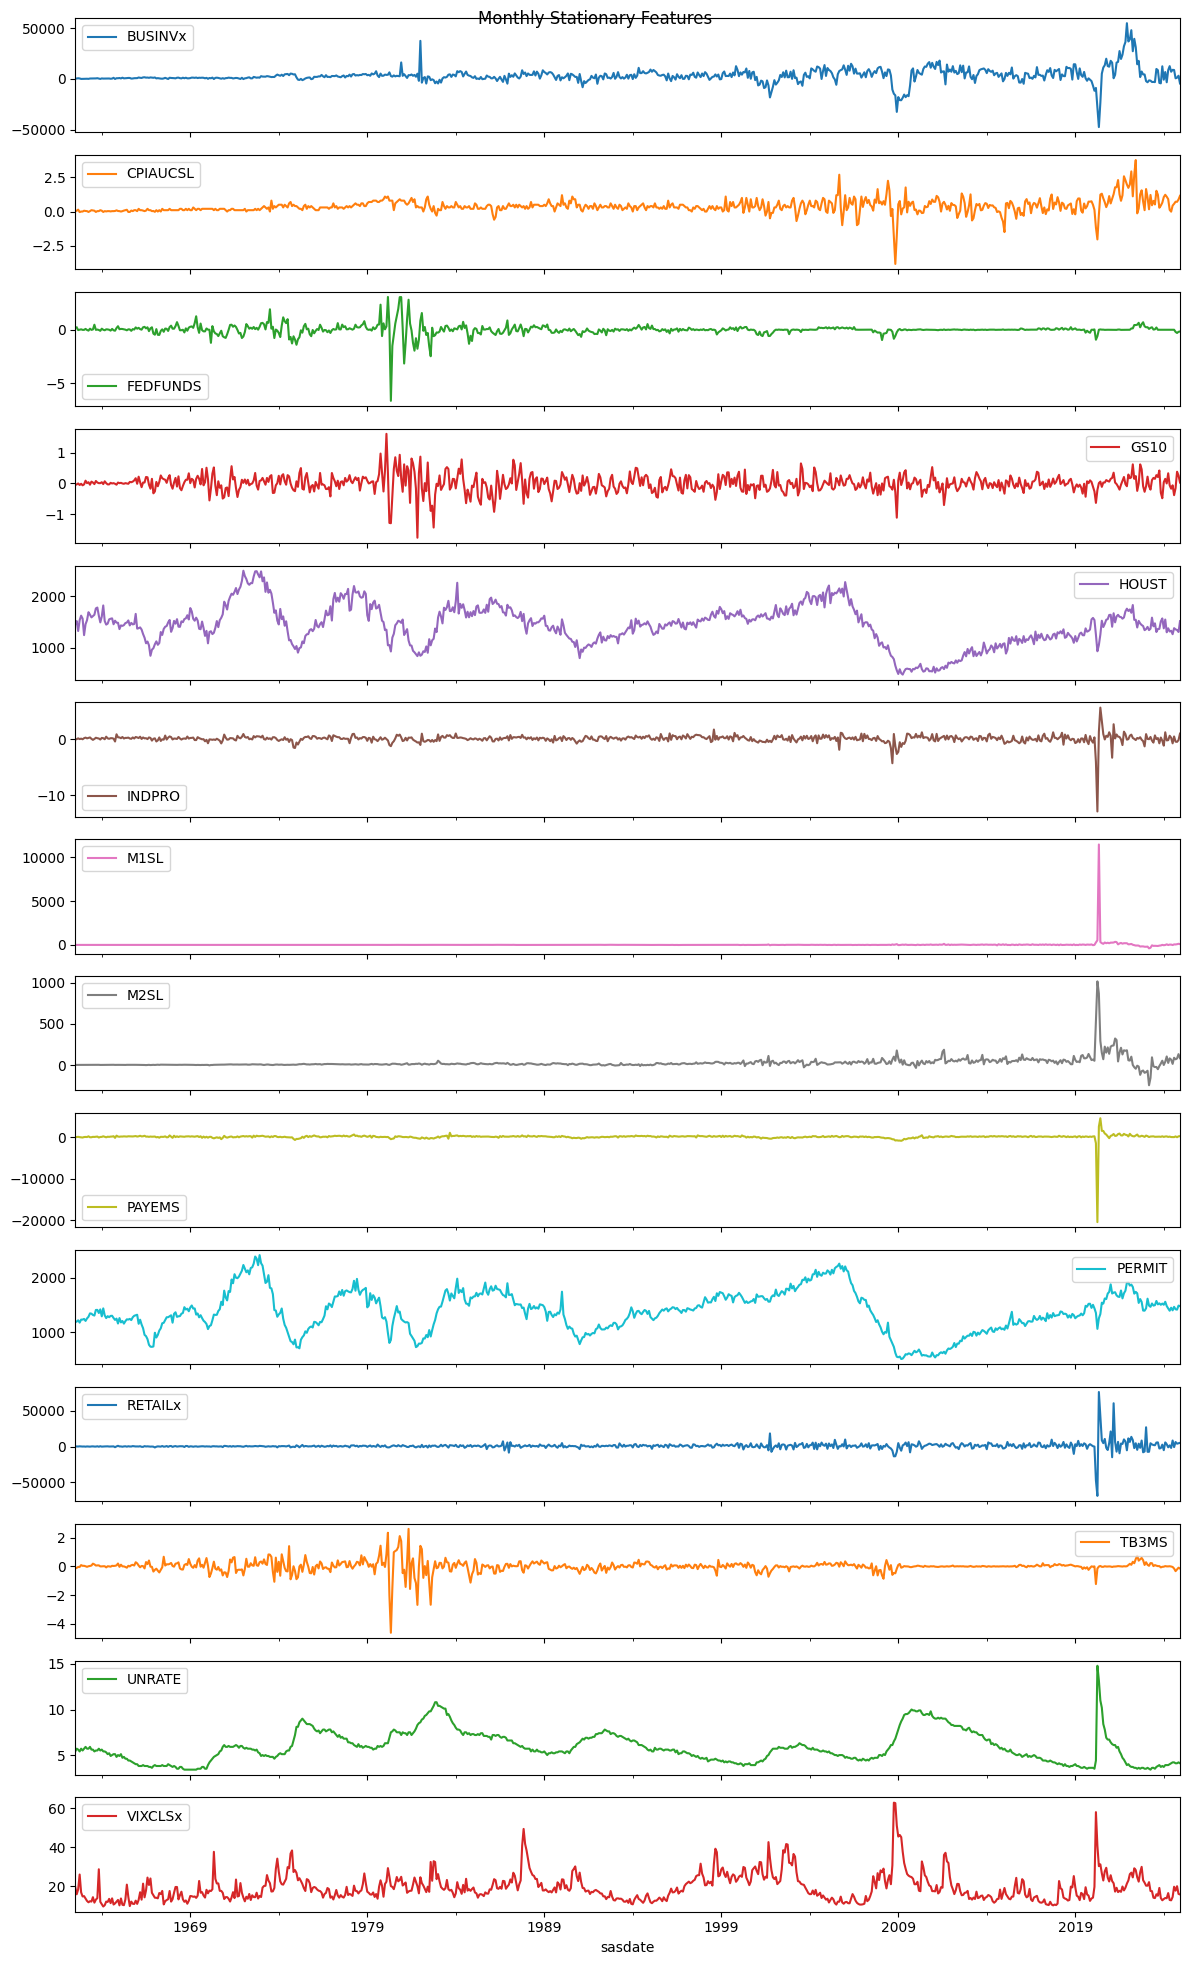

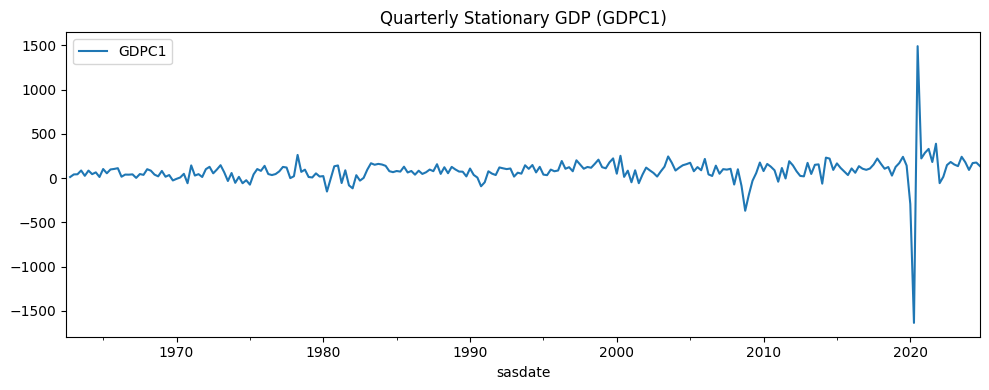

In [144]:
# Plotting
final_monthly_stationary.plot(subplots=True, figsize=(12, 20), title="Monthly Stationary Features")
plt.tight_layout()
plt.show()

final_quarterly_stationary.plot(figsize=(10, 4), title="Quarterly Stationary GDP (GDPC1)")
plt.tight_layout()
plt.show()

Standardize both datasets are now standardized (mean = 0, std = 1) 

In [145]:
# Initialize scaler
scaler_monthly = StandardScaler()
scaler_quarterly = StandardScaler()

# Standardize monthly and quarterly datasets
monthly_standardized = pd.DataFrame(
    scaler_monthly.fit_transform(final_monthly_stationary),
    index=final_monthly_stationary.index,
    columns=final_monthly_stationary.columns
)

quarterly_standardized = pd.DataFrame(
    scaler_quarterly.fit_transform(final_quarterly_stationary),
    index=final_quarterly_stationary.index,
    columns=final_quarterly_stationary.columns
)

# Output sample
monthly_standardized.head(), quarterly_standardized.head()


(             BUSINVx  CPIAUCSL  FEDFUNDS      GS10     HOUST    INDPRO  \
 sasdate                                                                  
 1962-07-01       NaN       NaN       NaN       NaN  0.037371       NaN   
 1962-08-01 -0.397851 -0.639688  0.433977 -0.109504  0.210000 -0.101994   
 1962-09-01 -0.365255 -0.481588 -0.064534 -0.001821 -0.287277  0.076776   
 1962-10-01 -0.392418 -0.837312 -0.004712 -0.181292  0.251226 -0.101994   
 1962-11-01 -0.457608 -0.758262  0.075049 -0.037715  0.480540  0.005215   
 
                 M1SL      M2SL    PAYEMS    PERMIT   RETAILx     TB3MS  \
 sasdate                                                                  
 1962-07-01       NaN       NaN       NaN -0.519238       NaN       NaN   
 1962-08-01 -0.057712 -0.396649 -0.056559 -0.490214 -0.141695 -0.243707   
 1962-09-01 -0.058661 -0.395141  0.002773 -0.429529 -0.152967 -0.100072   
 1962-10-01 -0.057000 -0.392125 -0.092406 -0.540346 -0.107878 -0.100072   
 1962-11-01 -0.056525 -

# model 1


For model 1, additional preprocessing is needed. 
We need to:

Repeat each quarterly value 3× → this gives us 249 × 3 = 747 values

Set this repeated series to match the monthly index

That way, each quarterly value is aligned with 3 consecutive months.

In [146]:
# Step 1: Repeat each quarterly observation 3 times
quarterly_repeated_values = quarterly_standardized.loc[quarterly_standardized.index.repeat(3)].reset_index(drop=True)

# Step 2: Use the last 747 months (to match the repeated quarterly series)
aligned_monthly = monthly_standardized.iloc[-len(quarterly_repeated_values):].copy()

# Step 3: Assign matching monthly index to repeated quarterly values
quarterly_repeated_values.index = aligned_monthly.index

# Final aligned series
aligned_quarterly = quarterly_repeated_values.copy()

# Confirm shapes
print(aligned_monthly.shape), print(aligned_quarterly.shape)

# Output sample
aligned_monthly.head(), aligned_quarterly.head()

(750, 14)
(750, 1)


(             BUSINVx  CPIAUCSL  FEDFUNDS      GS10     HOUST    INDPRO  \
 sasdate                                                                  
 1962-07-01       NaN       NaN       NaN       NaN  0.037371       NaN   
 1962-08-01 -0.397851 -0.639688  0.433977 -0.109504  0.210000 -0.101994   
 1962-09-01 -0.365255 -0.481588 -0.064534 -0.001821 -0.287277  0.076776   
 1962-10-01 -0.392418 -0.837312 -0.004712 -0.181292  0.251226 -0.101994   
 1962-11-01 -0.457608 -0.758262  0.075049 -0.037715  0.480540  0.005215   
 
                 M1SL      M2SL    PAYEMS    PERMIT   RETAILx     TB3MS  \
 sasdate                                                                  
 1962-07-01       NaN       NaN       NaN -0.519238       NaN       NaN   
 1962-08-01 -0.057712 -0.396649 -0.056559 -0.490214 -0.141695 -0.243707   
 1962-09-01 -0.058661 -0.395141  0.002773 -0.429529 -0.152967 -0.100072   
 1962-10-01 -0.057000 -0.392125 -0.092406 -0.540346 -0.107878 -0.100072   
 1962-11-01 -0.056525 -

Train and test split 

Monthly: (525, 14) (112, 14) (113, 14)
Quarterly: (525, 1) (112, 1) (113, 1)
             BUSINVx  CPIAUCSL  FEDFUNDS      GS10     HOUST    INDPRO  \
sasdate                                                                  
1962-07-01       NaN       NaN       NaN       NaN  0.037371       NaN   
1962-08-01 -0.397851 -0.639688  0.433977 -0.109504  0.210000 -0.101994   
1962-09-01 -0.365255 -0.481588 -0.064534 -0.001821 -0.287277  0.076776   
1962-10-01 -0.392418 -0.837312 -0.004712 -0.181292  0.251226 -0.101994   
1962-11-01 -0.457608 -0.758262  0.075049 -0.037715  0.480540  0.005215   
...              ...       ...       ...       ...       ...       ...   
2005-11-01  0.849819 -2.734504  0.433977  0.285333  1.833237  1.272832   
2005-12-01  1.405801 -0.758262  0.314335 -0.253080  1.439023  0.488319   
2006-01-01  0.810365  1.613228  0.254513 -0.181292  2.157885  0.067997   
2006-02-01  0.093499 -0.560638  0.394096  0.536592  1.761094 -0.082308   
2006-03-01  1.348223 -0.165390  0.1

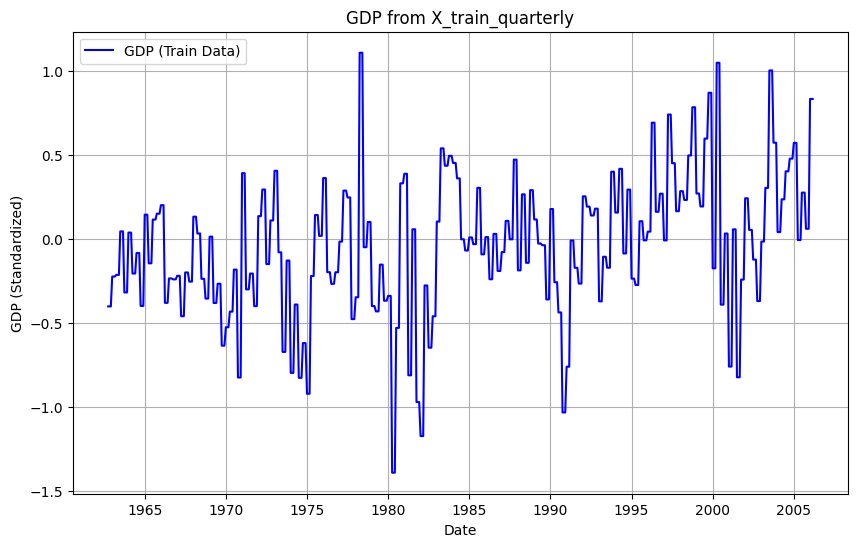

In [147]:
# Step 3: Split proportions
train_size = 0.7
val_size = 0.15
test_size = 0.15

# Step 4: Split indices
n = len(aligned_monthly)
train_end = int(n * train_size)
val_end = train_end + int(n * val_size)

# Step 5: Create splits
X_train_monthly = aligned_monthly.iloc[:train_end]
X_val_monthly = aligned_monthly.iloc[train_end:val_end]
X_test_monthly = aligned_monthly.iloc[val_end:]

X_train_quarterly = aligned_quarterly.iloc[:train_end]
X_val_quarterly = aligned_quarterly.iloc[train_end:val_end]
X_test_quarterly = aligned_quarterly.iloc[val_end:]

# Confirm shapes
print("Monthly:", X_train_monthly.shape, X_val_monthly.shape, X_test_monthly.shape)
print("Quarterly:", X_train_quarterly.shape, X_val_quarterly.shape, X_test_quarterly.shape)

print(X_train_monthly)
print(X_train_quarterly)

# Plot GDP from X_train_quarterly
plt.figure(figsize=(10, 6))
plt.plot(X_train_quarterly.index, X_train_quarterly["GDPC1"], label="GDP (Train Data)", color="blue")
plt.title("GDP from X_train_quarterly")
plt.xlabel("Date")
plt.ylabel("GDP (Standardized)")
plt.legend()
plt.grid(True)
plt.show()

In [148]:
# Step 1: Initialize empty lists for x and y
x_data_monthly = []
x_data_quarterly = []
y_data = []

for i in range(len(X_train_monthly) - sequence_length - 3):  # -3 to account for the next quarter
    x_seq_monthly = X_train_monthly.iloc[i:i + sequence_length].values
    x_seq_quarterly = X_train_quarterly.iloc[i:i + sequence_length].values
    x_data_monthly.append(x_seq_monthly)
    x_data_quarterly.append(x_seq_quarterly)

    y_seq = X_train_quarterly.iloc[i + sequence_length + 2]["GDPC1"]
    y_data.append(y_seq)

# Convert lists to numpy arrays
x_data_monthly = np.array(x_data_monthly)
x_data_quarterly = np.array(x_data_quarterly)

# Step 3: Convert lists to numpy arrays
x_data_md = np.array(x_data_monthly)
x_data_qd = np.array(x_data_quarterly)
y_data = np.array(y_data)[..., None]

# Output shapes
print("x_data_md shape:", x_data_md.shape)
print("x_data_qd shape:", x_data_qd.shape)
print("y_data shape:", y_data.shape)

x_data_md shape: (510, 12, 14)
x_data_qd shape: (510, 12, 1)
y_data shape: (510, 1)


In [149]:
# Step 1: Initialize empty lists for validation x and y
x_val_data_monthly = []
x_val_data_quarterly = []
y_val_data = []

# Step 2: Iterate through the validation data to create sequences
for i in range(len(X_val_monthly) - sequence_length - 3):  # -3 to account for the next quarter
    x_seq_monthly = X_val_monthly.iloc[i:i + sequence_length].values
    x_seq_quarterly = X_val_quarterly.iloc[i:i + sequence_length].values
    x_val_data_monthly.append(x_seq_monthly)
    x_val_data_quarterly.append(x_seq_quarterly)
    
    y_value_val = X_val_quarterly.iloc[i + sequence_length + 2]["GDPC1"]  # +2 to get the last month of the next quarter
    y_val_data.append(y_value_val)

# Step 3: Convert lists to numpy arrays
x_val_data_md = np.array(x_val_data_monthly)
x_val_data_qd = np.array(x_val_data_quarterly)
y_val_data = np.array(y_val_data)[..., None]

# Output shapes
print("x_val_data_md shape:", x_val_data_md.shape)
print("x_val_data_qd shape:", x_val_data_qd.shape)
print("y_val_data shape:", y_val_data.shape)

x_val_data_md shape: (97, 12, 14)
x_val_data_qd shape: (97, 12, 1)
y_val_data shape: (97, 1)


In [150]:
print("test")

test


In [151]:
# Set sequence length (can adjust)
sequence_length = 12  # one year

# Step 1: Define inputs
monthly_input = Input(shape=(sequence_length, X_train_monthly.shape[1]), name="monthly_input")
quarterly_input = Input(shape=(sequence_length, 1), name="quarterly_input")

# Step 2: Concatenate monthly + quarterly input along feature axis
combined_input = Concatenate(axis=-1)([monthly_input, quarterly_input])

# Step 3: LSTM model
x = LSTM(64, return_sequences=True)(combined_input)
output = TimeDistributed(Dense(1))(x)

# Step 4: Define model
model = Model(inputs=[monthly_input, quarterly_input], outputs=output)
model.compile(optimizer="adam", loss="mse")

# Summary
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ monthly_input       │ (None, 12, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ quarterly_input     │ (None, 12, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 12, 15)    │          0 │ monthly_input[0]… │
│ (Concatenate)       │                   │            │ quarterly_input[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_9 (LSTM)       │ (None, 12, 64)    │     20,480 │ concatenate_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 12, 1)     │         65 │ lstm_9[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,545 (80.25 KB)

 Trainable params: 20,545 (80.25 KB)

 Non-trainable params: 0 (0.00 B)

start taining
Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: nan - val_loss: nan
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: nan - val_loss: nan
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: nan - val_loss: nan
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: nan - val_loss: nan
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

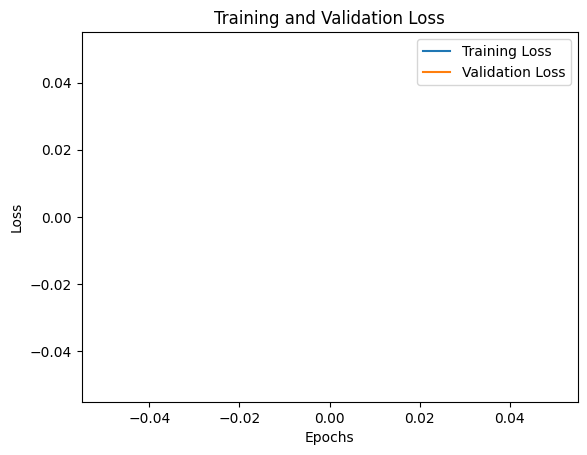

Validation Loss: nan


In [152]:
# Step 1: Train the model
print("start taining")

history = model.fit(
    [x_data_md[:400], x_data_qd[:400]],  # Inputs: monthly and quarterly sequences
    y_data[:400],                  # Target: next quarter GDP
    validation_data=([x_data_md[400:], x_data_qd[400:]], y_data[400:]),  # Validation data
    # validation_data=([x_val_data_md, x_val_data_qd], y_val_data),  # Validation data
    epochs=50,               # Number of epochs
    batch_size=32,           # Batch size
    verbose=1                # Verbosity level
)

# Step 2: Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Step 3: Evaluate the model on validation data
val_loss = model.evaluate([x_val_data_md, x_val_data_qd], y_val_data, verbose=0)
print(f"Validation Loss: {val_loss}")

In [153]:
help(model.fit)

Help on method fit in module keras.src.backend.tensorflow.trainer:

fit(x=None, y=None, batch_size=None, epochs=1, verbose='auto', callbacks=None, validation_split=0.0, validation_data=None, shuffle=True, class_weight=None, sample_weight=None, initial_epoch=0, steps_per_epoch=None, validation_steps=None, validation_batch_size=None, validation_freq=1) method of keras.src.models.functional.Functional instance
    Trains the model for a fixed number of epochs (dataset iterations).

    Args:
        x: Input data. It can be:
            - A NumPy array (or array-like), or a list of arrays
            (in case the model has multiple inputs).
            - A backend-native tensor, or a list of tensors
            (in case the model has multiple inputs).
            - A dict mapping input names to the corresponding array/tensors,
            if the model has named inputs.
            - A `keras.utils.PyDataset` returning `(inputs, targets)` or
            `(inputs, targets, sample_weights)`.